Processing 3D plots for ReA2B...
Saved: ReA2B_PL-4_WithFit_3D.pdf


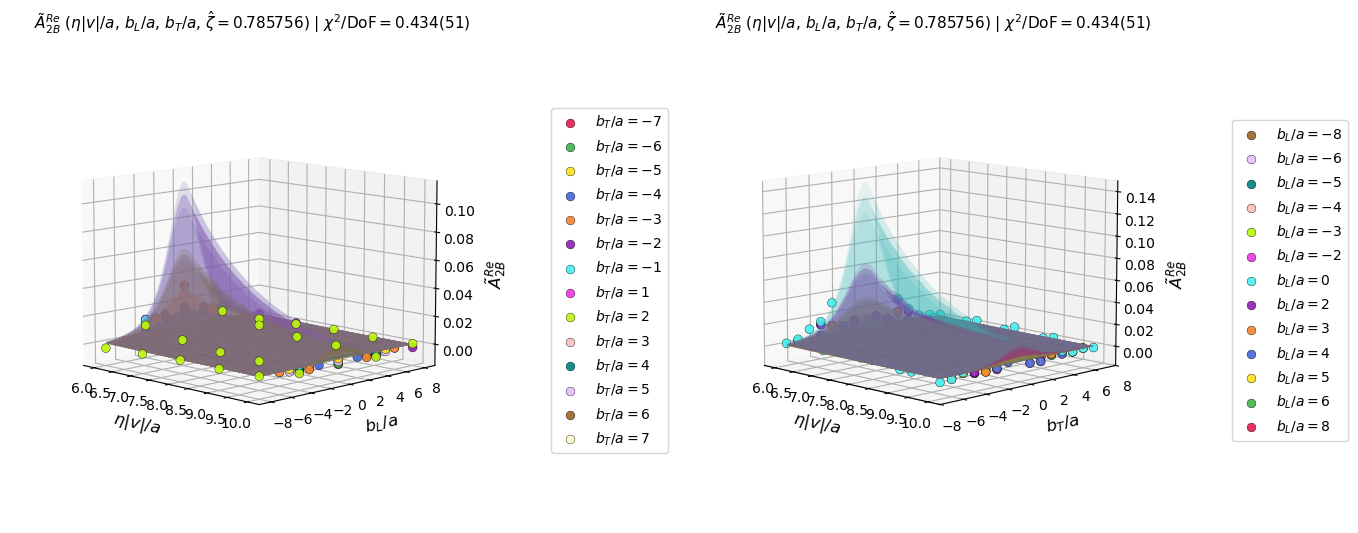

Processing 3D plots for ImA2B...
Saved: ImA2B_PL-4_WithFit_3D.pdf


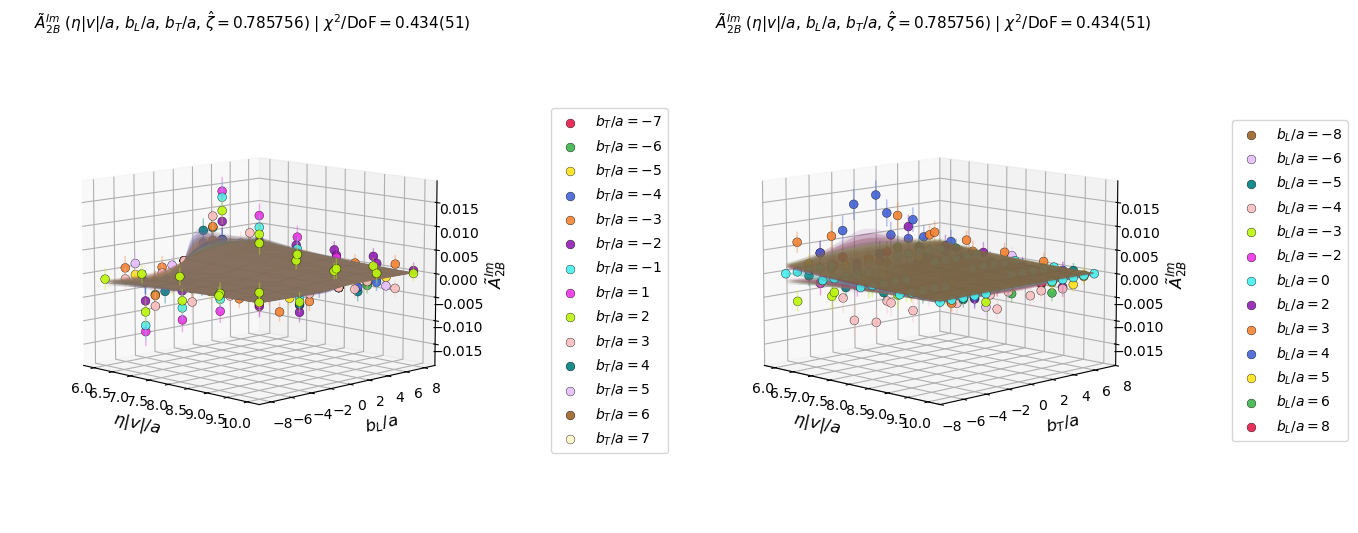

Processing 3D plots for ReA12B...
Saved: ReA12B_PL-4_WithFit_3D.pdf


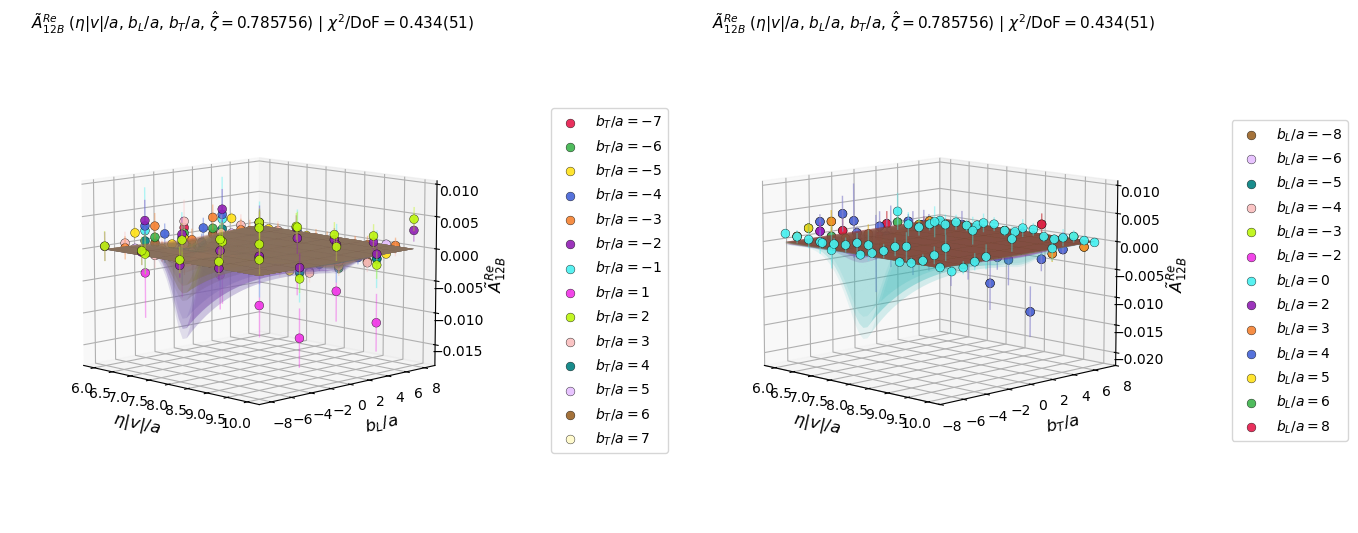

Processing 2D plots at fixed eta=8...
Saved: Combined_eta8_PL-4_WithFit_2D.pdf


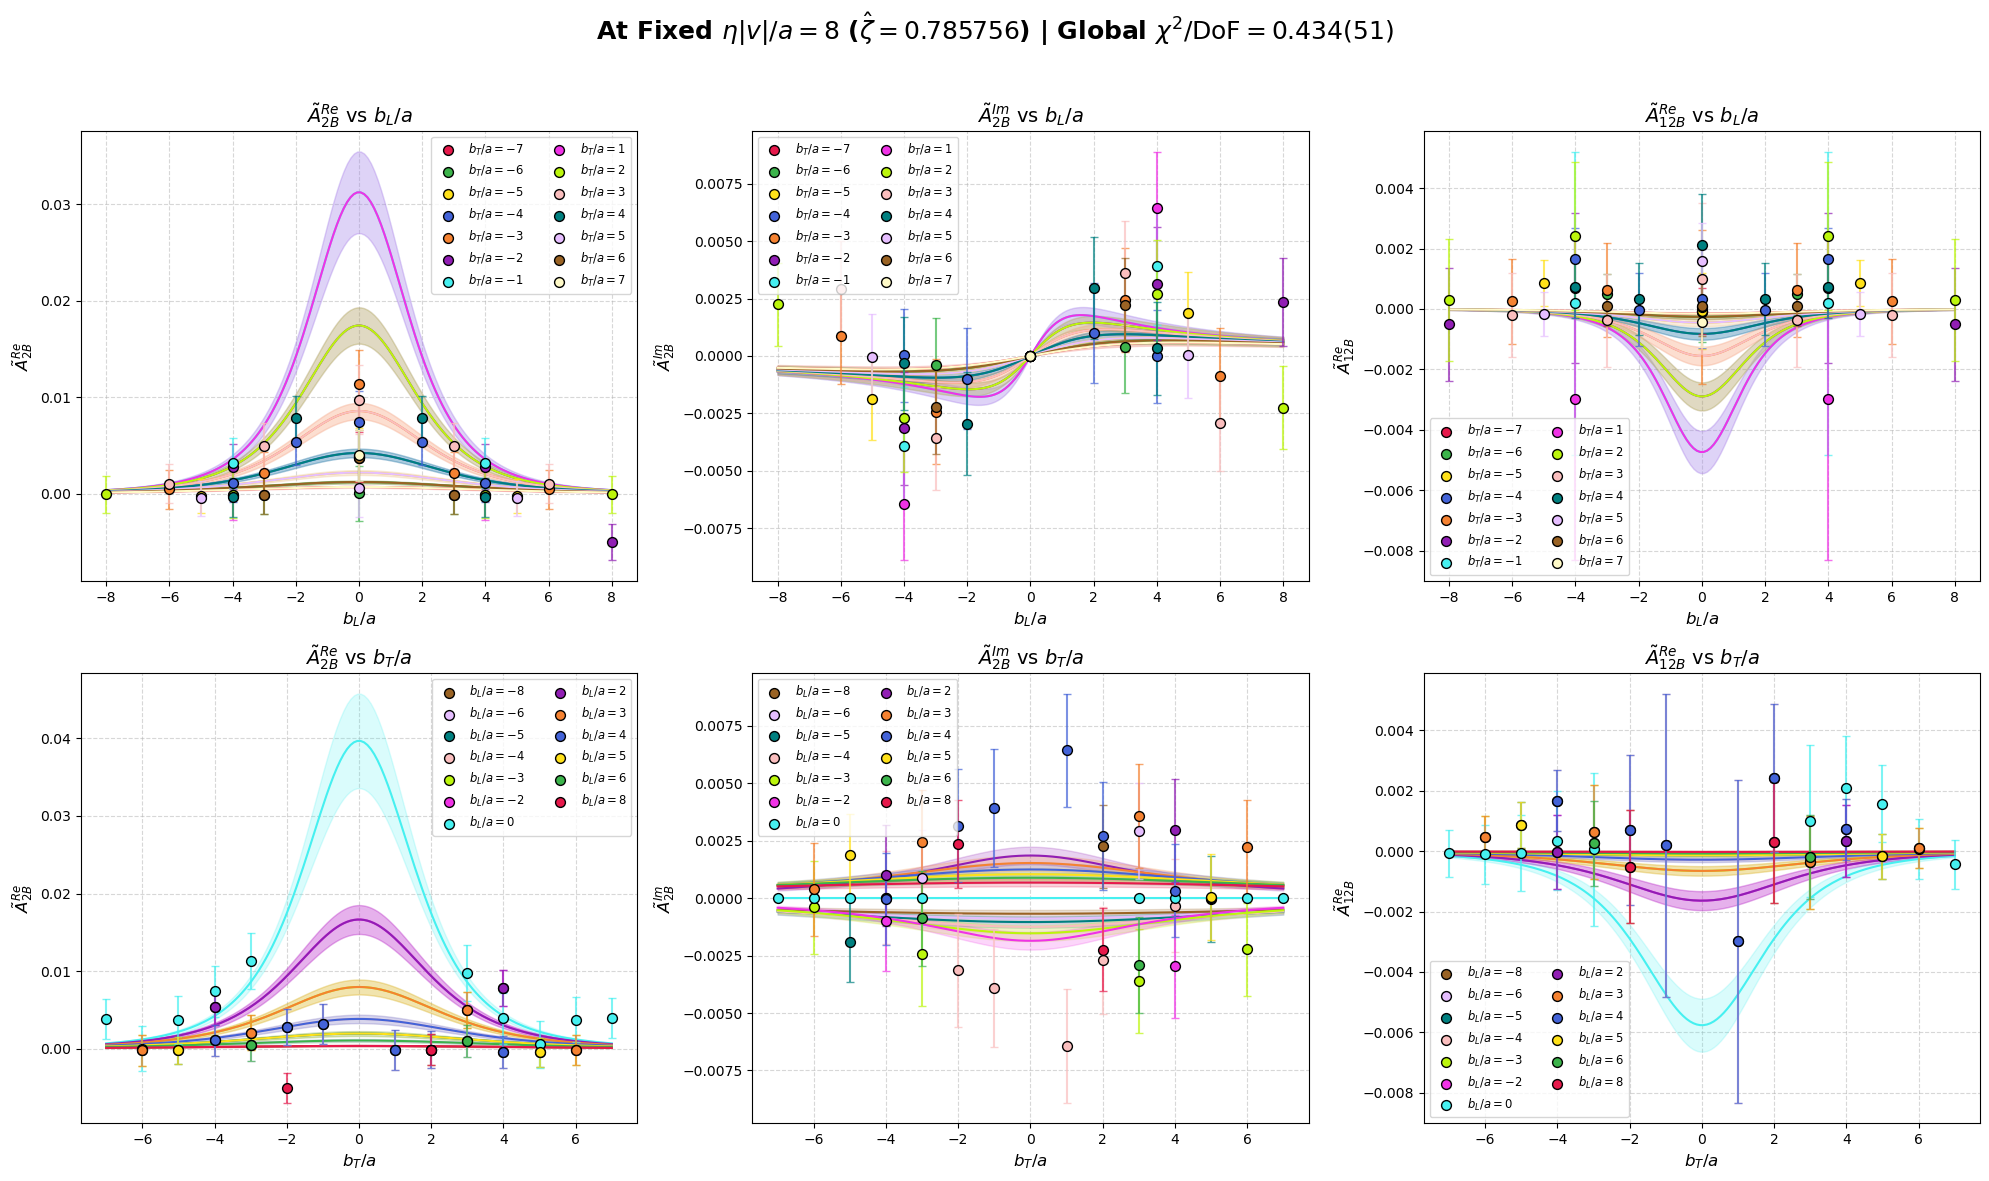

In [20]:
import h5py
import numpy as np
import math
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# --- 1. Jackknife Functions ---
def jackknife_vectorized(samples):
    N = samples.shape[1]
    theta_bar = np.mean(samples, axis=1)
    squared_diffs = np.square(samples - theta_bar[:, None])
    sigma_sq = ((N - 1) / N) * np.sum(squared_diffs, axis=1)
    error = np.sqrt(sigma_sq)
    return theta_bar, error

def Jackknife(datalist): 
    N = len(datalist)
    theta_bar = np.mean(datalist)
    theta_nminus_theta_bar = []
    for i in range(N): 
        theta_n = datalist[i]
        theta_nminus_theta_bar.append(np.square(theta_n - theta_bar))
    sigma_sq = ((N-1)/N) * np.sum(theta_nminus_theta_bar)
    return theta_bar, np.sqrt(sigma_sq)

def fmt_err(mean, err):
    # Fallback for 0 or negative error
    if err <= 0:
        return f"{mean}"
        
    # Switch to scientific if very small/big
    if mean and (abs(mean) < 1e-3 or abs(mean) >= 1e3):
        # Calculate exponent of the mean
        exp = int(math.floor(math.log10(abs(mean))))
        mean_scaled = mean / 10**exp
        err_scaled = err / 10**exp
        
        # Find precision needed for exactly 2 significant digits of the error
        place = int(math.floor(math.log10(abs(err_scaled))))
        ndec = max(0, -(place - 1))
        
        m_str = f"{mean_scaled:.{ndec}f}"
        err_int = int(round(err_scaled * 10**ndec))
        return f"{m_str}({err_int})e{exp}"
        
    else:
        # Find precision needed for exactly 2 significant digits of the error
        place = int(math.floor(math.log10(abs(err))))
        ndec = max(0, -(place - 1))  # -1 gives us 2 sig figs instead of 1
        
        m_str = f"{mean:.{ndec}f}"
        err_int = int(round(err * 10**ndec))
        return f"{m_str}({err_int})"
        
pl_to_zeta = {
    -4: 0.785756,
    -3: 0.539684,
    -2: 0.294367,
    -1: 0.090772
}

# --- 2. Data Loading Helper ---
def get_processed_amplitude_data(filepath):
    try:
        with h5py.File(filepath, "r") as f:
            raw_data = f["Dataset1"][:]
    except FileNotFoundError:
        print(f"File not found: {filepath}")
        return None

    kin = raw_data[:, 0:3]
    samples = raw_data[:, 3:]
    
    eta, bL, bT = kin[:, 0], kin[:, 1], kin[:, 2]
    
    # Filter only for eta from 1 to 10 (keeps bL=bT=0 and eta=1..5)
    mask_eta = (eta >= 6) & (eta <= 10) & (np.sqrt(bL**2+bT**2)>=3)
    eta_f, bL_f, bT_f = eta[mask_eta], bL[mask_eta], bT[mask_eta]
    
    mean_f, err_f = jackknife_vectorized(samples[mask_eta])
    
    return {
        'eta': eta_f, 'bL': bL_f, 'bT': bT_f,
        'mean': mean_f, 'error': err_f,
        'unique_bL': np.unique(bL_f), 'unique_bT': np.unique(bT_f),
        'r': np.sqrt(bL_f**2 + bT_f**2)
    }

# --- 3. STRICTLY Distinct Color Generator ---
def get_distinct_colors(num_colors):
    """Returns a list of highly distinct, non-gradient colors."""
    distinct_hex = [
        '#e6194b', '#3cb44b', '#ffe119', '#4363d8', '#f58231',
        '#911eb4', '#46f0f0', '#f032e6', '#bcf60c', '#fabebe',
        '#008080', '#e6beff', '#9a6324', '#fffac8', '#800000',
        '#aaffc3', '#808000', '#ffd8b1', '#000075', '#808080',
        '#000000', '#333333'
    ]
    return [distinct_hex[i % len(distinct_hex)] for i in range(num_colors)]

# --- 4. Fit Evaluation Helper ---
def eval_fit_jk(amp_name, eta, bL, bT, params):
    """Evaluates the fit model over input arrays and returns the Jackknife mean and error."""
    eta = np.atleast_1d(eta)
    bL = np.atleast_1d(bL)
    bT = np.atleast_1d(bT)
    
    if amp_name == "ReA2B":
        a, c, d, f = params['a_re'], params['c_re'], params['d_re'], params['f']
        k1, k2, j = params['k1_re'], params['k2_re'], params['j_re']
        
        a, c, d, f = a[:, None], c[:, None], d[:, None], f[:, None]
        k1, k2, j = k1[:, None], k2[:, None], j[:, None]
        
        denom = (1 + (d + c * (1 - k1/eta - k2/eta**2)) * bL**2 + d * bT**2)**j
        val = a * np.exp(-f * eta) / denom
        
    elif amp_name == "ImA2B":
        a, c, d, f = params['a_im'], params['c_im'], params['d_im'], params['f']
        j = params['j_im']
        a, c, d, f, j = a[:, None], c[:, None], d[:, None], f[:, None], j[:, None]
        
        denom = (1 + (c + d) * bL**2 + d * bT**2)**j
        val = a * bL * np.exp(-f * eta) / denom
        
    elif amp_name == "ReA12B":
        a, c, d, f = params['a_reA12B'], params['c_reA12B'], params['d_reA12B'], params['f']
        j = params['j_reA12B']
        a, c, d, f, j = a[:, None], c[:, None], d[:, None], f[:, None], j[:, None]
        
        denom = (1 + (c + d) * bL**2 + d * bT**2)**j
        val = -a * np.exp(-f * eta) / denom
        
    N = val.shape[0]
    mean_val = np.mean(val, axis=0)
    squared_diffs = np.square(val - mean_val)
    err_val = np.sqrt(((N - 1) / N) * np.sum(squared_diffs, axis=0))
    
    return mean_val, err_val

# --- 5. 3D Plotting Function ---
def plot_3d_for_amplitude(data, amp_name, PL, fitted_params, chi2_str):
    fig = plt.figure(figsize=(16, 9))
    
    if amp_name == "ReA2B":
        amp_print = "$\\tilde{{A}}_{{2B}}^{{Re}}$"
    elif amp_name == "ImA2B":
        amp_print = "$\\tilde{{A}}_{{2B}}^{{Im}}$"
    elif amp_name == "ReA12B":
        amp_print = "$\\tilde{{A}}_{{12B}}^{{Re}}$"
        
    # Valid global bounds for fit grid (strictly evaluated over the colored valid region)
    valid_global_mask = (data['r'] >= 3) & (data['eta'] >= 6)
    min_bL_fit = np.min(data['bL'][valid_global_mask])
    max_bL_fit = np.max(data['bL'][valid_global_mask])
    min_bT_fit = np.min(data['bT'][valid_global_mask])
    max_bT_fit = np.max(data['bT'][valid_global_mask])
    
    # Fit ETA grid strictly spans from 6 upward, avoiding 1-5
    eta_grid = np.linspace(6.0, np.max(data['eta']), 30)
    
    title_str = fr'{amp_print} ($\eta|v|/a$, $b_L/a$, $b_T/a$, $\hat{{\zeta}}={pl_to_zeta[int(PL)]}$) | $\chi^2/\mathrm{{DoF}}={chi2_str}$'
    
    # --- Plot 1: Color by distinct bT ---
    ax1 = fig.add_subplot(121, projection='3d')
    unique_bT = data['unique_bT']
    colors_bT = get_distinct_colors(len(unique_bT))
    
    for i, val_bT in enumerate(unique_bT):
        mask = (data['bT'] == val_bT)
        mask_valid = mask & (data['r'] >= 3) & (data['eta'] >= 6)
        mask_invalid = mask & ((data['r'] < 3) | (data['eta'] < 6))
        
        # Valid points (colored circles)
        if np.any(mask_valid):
            ax1.scatter(data['eta'][mask_valid], data['bL'][mask_valid], data['mean'][mask_valid], 
                        color=colors_bT[i], label=fr'$b_T/a={val_bT:.0f}$', 
                        marker='o', s=40, alpha=0.9, edgecolors='k', linewidth=0.3)
            ax1.errorbar(data['eta'][mask_valid], data['bL'][mask_valid], data['mean'][mask_valid], 
                         zerr=data['error'][mask_valid], fmt='none', ecolor=colors_bT[i], 
                         alpha=0.4, linewidth=1.0, zorder=0)
                         
            # Fit Surface over full valid range
            bL_grid = np.linspace(min_bL_fit, max_bL_fit, 40)
            ETA, BL = np.meshgrid(eta_grid, bL_grid)
            
            mean_surf, err_surf = eval_fit_jk(amp_name, ETA.flatten(), BL.flatten(), np.full_like(ETA.flatten(), val_bT), fitted_params)
            mean_surf = mean_surf.reshape(ETA.shape)
            err_surf = err_surf.reshape(ETA.shape)
            
            ax1.plot_surface(ETA, BL, mean_surf, color=colors_bT[i], alpha=0.2, rstride=5, cstride=5)
            ax1.plot_surface(ETA, BL, mean_surf + err_surf, color=colors_bT[i], alpha=0.1, rstride=5, cstride=5)
            ax1.plot_surface(ETA, BL, mean_surf - err_surf, color=colors_bT[i], alpha=0.1, rstride=5, cstride=5)

        # Invalid points (gray 'x')
        if np.any(mask_invalid):
            ax1.scatter(data['eta'][mask_invalid], data['bL'][mask_invalid], data['mean'][mask_invalid], 
                        color='gray', marker='x', s=35, alpha=0.7)
            ax1.errorbar(data['eta'][mask_invalid], data['bL'][mask_invalid], data['mean'][mask_invalid], 
                         zerr=data['error'][mask_invalid], fmt='none', ecolor='gray', 
                         alpha=0.4, linewidth=1.0, zorder=0)

    ax1.set_xlabel(r'$\eta|v|/a$', fontsize=12, labelpad=10)
    ax1.set_ylabel(r'$b_L/a$', fontsize=12, labelpad=10)
    ax1.set_zlabel(f'{amp_print}', fontsize=12, labelpad=10)
    ax1.set_title(title_str, fontsize=11)
    ax1.legend(loc='center left', bbox_to_anchor=(1.1, 0.5), ncol=1)

    # --- Plot 2: Color by distinct bL ---
    ax2 = fig.add_subplot(122, projection='3d')
    unique_bL = data['unique_bL']
    colors_bL = get_distinct_colors(len(unique_bL))[::-1] 

    for i, val_bL in enumerate(unique_bL):
        mask = (data['bL'] == val_bL)
        mask_valid = mask & (data['r'] >= 3) & (data['eta'] >= 6)
        mask_invalid = mask & ((data['r'] < 3) | (data['eta'] < 6))
        
        # Valid points (colored circles)
        if np.any(mask_valid):
            ax2.scatter(data['eta'][mask_valid], data['bT'][mask_valid], data['mean'][mask_valid], 
                        color=colors_bL[i], label=fr'$b_L/a={val_bL:.0f}$', 
                        marker='o', s=40, alpha=0.9, edgecolors='k', linewidth=0.3)
            ax2.errorbar(data['eta'][mask_valid], data['bT'][mask_valid], data['mean'][mask_valid], 
                         zerr=data['error'][mask_valid], fmt='none', ecolor=colors_bL[i], 
                         alpha=0.4, linewidth=1.0, zorder=0)

            # Fit Surface over full valid range
            bT_grid = np.linspace(min_bT_fit, max_bT_fit, 40)
            ETA, BT = np.meshgrid(eta_grid, bT_grid)
            
            mean_surf, err_surf = eval_fit_jk(amp_name, ETA.flatten(), np.full_like(ETA.flatten(), val_bL), BT.flatten(), fitted_params)
            mean_surf = mean_surf.reshape(ETA.shape)
            err_surf = err_surf.reshape(ETA.shape)
            
            ax2.plot_surface(ETA, BT, mean_surf, color=colors_bL[i], alpha=0.2, rstride=5, cstride=5)
            ax2.plot_surface(ETA, BT, mean_surf + err_surf, color=colors_bL[i], alpha=0.1, rstride=5, cstride=5)
            ax2.plot_surface(ETA, BT, mean_surf - err_surf, color=colors_bL[i], alpha=0.1, rstride=5, cstride=5)

        # Invalid points (gray 'x')
        if np.any(mask_invalid):
            ax2.scatter(data['eta'][mask_invalid], data['bT'][mask_invalid], data['mean'][mask_invalid], 
                        color='gray', marker='x', s=35, alpha=0.7)
            ax2.errorbar(data['eta'][mask_invalid], data['bT'][mask_invalid], data['mean'][mask_invalid], 
                         zerr=data['error'][mask_invalid], fmt='none', ecolor='gray', 
                         alpha=0.4, linewidth=1.0, zorder=0)

    ax2.set_xlabel(r'$\eta|v|/a$', fontsize=12, labelpad=10)
    ax2.set_ylabel(r'$b_T/a$', fontsize=12, labelpad=10)
    ax2.set_zlabel(f'{amp_print}', fontsize=12, labelpad=10)
    ax2.set_title(title_str, fontsize=11)
    ax2.legend(loc='center left', bbox_to_anchor=(1.1, 0.5), ncol=1)

    ax1.view_init(elev=10, azim=-45) 
    ax2.view_init(elev=10, azim=-45)

    try:
        ax1.set_box_aspect(None, zoom=0.8)
        ax2.set_box_aspect(None, zoom=0.8)
    except AttributeError:
        ax1.dist = 11
        ax2.dist = 11

    plt.tight_layout(rect=[0.02, 0.05, 0.88, 0.95])
    return fig

# --- 6. 2D Plot at fixed eta = 8 ---
def plot_2d_slice_eta8(all_data_dict, PL, fitted_params, chi2_str):
    fig, axes = plt.subplots(2, 3, figsize=(20, 12))
    fig.suptitle(fr'At Fixed $\eta|v|/a = 8$ ($\hat{{\zeta}}={pl_to_zeta[int(PL)]}$) | Global $\chi^2/\mathrm{{DoF}}={chi2_str}$', fontsize=18, fontweight='bold')
    
    for idx, (amp_name, data) in enumerate(all_data_dict.items()):
        if amp_name == "ReA2B":
            amp_print = "$\\tilde{{A}}_{{2B}}^{{Re}}$"
        elif amp_name == "ImA2B":
            amp_print = "$\\tilde{{A}}_{{2B}}^{{Im}}$"
        elif amp_name == "ReA12B":
            amp_print = "$\\tilde{{A}}_{{12B}}^{{Re}}$"
            
        if data is None: continue
        
        ax_top = axes[0, idx]
        ax_bot = axes[1, idx]
        
        mask_eta8 = np.isclose(data['eta'], 8.0)
        bL_8 = data['bL'][mask_eta8]
        bT_8 = data['bT'][mask_eta8]
        mean_8 = data['mean'][mask_eta8]
        err_8 = data['error'][mask_eta8]
        r_8 = data['r'][mask_eta8]
        
        # Valid bounds over the global set of valid colored points
        valid_global_mask = (data['r'] >= 3) & (data['eta'] >= 6)
        min_bL_fit = np.min(data['bL'][valid_global_mask])
        max_bL_fit = np.max(data['bL'][valid_global_mask])
        min_bT_fit = np.min(data['bT'][valid_global_mask])
        max_bT_fit = np.max(data['bT'][valid_global_mask])
        
        if len(bL_8) == 0:
            ax_top.text(0.5, 0.5, "No data", ha='center', va='center')
            ax_bot.text(0.5, 0.5, "No data", ha='center', va='center')
            continue
            
        # ==========================================
        # TOP ROW: Amplitude vs bL, colored by bT
        # ==========================================
        unique_bT = np.unique(bT_8)
        colors_bT = get_distinct_colors(len(unique_bT))
        
        for i, val_bT in enumerate(unique_bT):
            sub_mask = (bT_8 == val_bT)
            # Eta is strictly 8 here, so validity just depends on r
            mask_valid = sub_mask & (r_8 >= 3)
            mask_invalid = sub_mask & (r_8 < 3)
            
            # Valid points
            if np.any(mask_valid):
                ax_top.scatter(bL_8[mask_valid], mean_8[mask_valid], color=colors_bT[i], 
                               label=fr'$b_T/a={val_bT:.0f}$', marker='o', zorder=5, s=50, edgecolors='k')
                ax_top.errorbar(bL_8[mask_valid], mean_8[mask_valid], yerr=err_8[mask_valid], 
                                fmt='none', ecolor=colors_bT[i], alpha=0.7, zorder=4, capsize=3)
                
                # Fit Band over valid bL range
                bL_grid = np.linspace(min_bL_fit, max_bL_fit, 150)
                mean_fit, err_fit = eval_fit_jk(amp_name, np.full_like(bL_grid, 8.0), bL_grid, np.full_like(bL_grid, val_bT), fitted_params)
                ax_top.plot(bL_grid, mean_fit, color=colors_bT[i], linestyle='-', zorder=3)
                ax_top.fill_between(bL_grid, mean_fit - err_fit, mean_fit + err_fit, color=colors_bT[i], alpha=0.2, zorder=2)
            
            # Invalid points (including bL=0, bT=0 if present)
            if np.any(mask_invalid):
                ax_top.scatter(bL_8[mask_invalid], mean_8[mask_invalid], color='gray', marker='x', 
                               zorder=5, s=40)
                ax_top.errorbar(bL_8[mask_invalid], mean_8[mask_invalid], yerr=err_8[mask_invalid], 
                                fmt='none', ecolor='gray', alpha=0.7, zorder=4, capsize=3)
        
        ax_top.set_title(fr'{amp_print} vs $b_L/a$', fontsize=14)
        ax_top.set_xlabel(r'$b_L/a$', fontsize=12)
        ax_top.set_ylabel(f'{amp_print}', fontsize=12)
        ax_top.grid(True, linestyle='--', alpha=0.5)
        ax_top.legend(fontsize='small', loc='best', ncol=(1 if len(unique_bT) <= 6 else 2))

        # ==========================================
        # BOTTOM ROW: Amplitude vs bT, colored by bL
        # ==========================================
        unique_bL = np.unique(bL_8)
        colors_bL = get_distinct_colors(len(unique_bL))[::-1] 
        
        for i, val_bL in enumerate(unique_bL):
            sub_mask = (bL_8 == val_bL)
            mask_valid = sub_mask & (r_8 >= 3)
            mask_invalid = sub_mask & (r_8 < 3)
            
            # Valid points
            if np.any(mask_valid):
                ax_bot.scatter(bT_8[mask_valid], mean_8[mask_valid], color=colors_bL[i], 
                               label=fr'$b_L/a={val_bL:.0f}$', marker='o', zorder=5, s=50, edgecolors='k')
                ax_bot.errorbar(bT_8[mask_valid], mean_8[mask_valid], yerr=err_8[mask_valid], 
                                fmt='none', ecolor=colors_bL[i], alpha=0.7, zorder=4, capsize=3)
                
                # Fit Band over valid bT range
                bT_grid = np.linspace(min_bT_fit, max_bT_fit, 150)
                mean_fit, err_fit = eval_fit_jk(amp_name, np.full_like(bT_grid, 8.0), np.full_like(bT_grid, val_bL), bT_grid, fitted_params)
                ax_bot.plot(bT_grid, mean_fit, color=colors_bL[i], linestyle='-', zorder=3)
                ax_bot.fill_between(bT_grid, mean_fit - err_fit, mean_fit + err_fit, color=colors_bL[i], alpha=0.2, zorder=2)

            # Invalid points
            if np.any(mask_invalid):
                ax_bot.scatter(bT_8[mask_invalid], mean_8[mask_invalid], color='gray', marker='x', 
                               zorder=5, s=40)
                ax_bot.errorbar(bT_8[mask_invalid], mean_8[mask_invalid], yerr=err_8[mask_invalid], 
                                fmt='none', ecolor='gray', alpha=0.7, zorder=4, capsize=3)
        
        ax_bot.set_title(fr'{amp_print} vs $b_T/a$', fontsize=14)
        ax_bot.set_xlabel(r'$b_T/a$', fontsize=12)
        ax_bot.set_ylabel(f'{amp_print}', fontsize=12)
        ax_bot.grid(True, linestyle='--', alpha=0.5)
        ax_bot.legend(fontsize='small', loc='best', ncol=(1 if len(unique_bL) <= 6 else 2))

    plt.tight_layout(rect=[0, 0, 1, 0.96])
    return fig


def load_params_from_h5(filename):
    fitted_params = {}
    with h5py.File(filename, "r") as f:
        param_group = f["jackknife_samples"]
        for key in param_group.keys():
            fitted_params[key] = param_group[key][:]
        chi2_dof_list = f["chi2_dof"][:]
    return fitted_params, chi2_dof_list 

def print_latex_table(fitted_params, chi2_dof_list, PL, bmin, etamin, etamax, chi2_str):
    res = {}
    for key in fitted_params:
        mean, err = Jackknife(fitted_params[key])
        res[key] = fmt_err(mean, err)
        
    re_params = ['a_re', 'c_re', 'd_re', 'k1_re', 'k2_re', 'j_re', 'f']
    im_params = ['a_im', 'c_im', 'd_im', 'j_im', 'f']
    a12b_params = ['a_reA12B', 'c_reA12B', 'd_reA12B', 'j_reA12B', 'f']

    vals_re = ", ".join([res[p] for p in re_params])
    vals_im = ", ".join([res[p] for p in im_params])
    vals_a12b = ", ".join([res[p] for p in a12b_params])

    eq_re = r"$\frac{a e^{-f \eta}}{\left[1 + \left(d + c\left(1 - \frac{k_1}{\eta} - \frac{k_2}{\eta^2}\right)\right) b_L^2 + d b_T^2\right]^j}$"
    eq_im = r"$\frac{a b_L e^{-f \eta}}{\left[1 + (c + d) b_L^2 + d b_T^2\right]^j}$"
    eq_a12b = r"$\frac{-a e^{-f \eta}}{\left[1 + (c + d) b_L^2 + d b_T^2\right]^j}$"

    names_re = r"$\{a, c, d, k_1, k_2, j, f\}$"
    names_im = r"$\{a, c, d, j, f\}$"
    names_a12b = r"$\{a, c, d, j, f\}$"
    
    tex = "\\begin{table}[htpb]\n\\centering\n"
    tex += "\\renewcommand{\\arraystretch}{1.5}\n" 
    tex += f"\\caption{{Simultaneous Fit with common $f$: for $P_L={PL}$, $b_{{min}} \\ge {bmin}$, $\\eta \\in [{etamin}, {etamax}]$. Global $\\chi^2/\\text{{DoF}} = {chi2_str}$}}\n"
    tex += "\\scalebox{0.8}{\\begin{tabular}{|l|l|l|l|}\n\\hline\n"
    tex += "Amplitude & Model Expression & Params List & Fitted Values \\\\\n\\hline\n"
    tex += f"Re$A_{{2B}}$ & {eq_re} & {names_re} & $[{vals_re}]$ \\\\\n"
    tex += f"Im$A_{{2B}}$ & {eq_im} & {names_im} & $[{vals_im}]$ \\\\\n"
    tex += f"Re$A_{{12B}}$ & {eq_a12b} & {names_a12b} & $[{vals_a12b}]$ \\\\\n"
    tex += "\\hline\n\\end{tabular}}\n\\end{table}\n"

    filename = f"Fit_Table_PL{PL}_bmin{bmin}.tex"
    with open(filename, "w") as f:
        f.write(tex)

# ==========================================
# Main Execution Block
# ==========================================
PL_value = "-4" 
bminfit = 3
etamin = 6
etamax = 10
path_base = "/pscratch/sd/h/hari_8/TMD_fit/h5data"

# 1. Load fitted parameters
fit_file = f"{path_base}/FitParams_SimulFit_f_A2BRe_cetasq_A2BIm_A12BRe_bmin{bminfit}_eta{etamin}{etamax}_PL{PL_value}.h5"
fitted_params, chi2_dof_list = load_params_from_h5(fit_file)

# Compute chi2 string here so we can pass it to the plotting functions
mean_chi2, err_chi2 = Jackknife(chi2_dof_list)
chi2_str = fmt_err(mean_chi2, err_chi2)

# Update print table to receive chi2_str
print_latex_table(fitted_params, chi2_dof_list, PL_value, bminfit, etamin, etamax, chi2_str)

# 2. Data loading paths
amplitude_files = {
    "ReA2B":  f"{path_base}/ReA2B_PL{PL_value}_jackknife_data.h5",
    "ImA2B":  f"{path_base}/ImA2B_PL{PL_value}_jackknife_data.h5",
    "ReA12B": f"{path_base}/ReA12B_PL{PL_value}_jackknife_data.h5"
}

processed_data_store = {}

# 3. Generate and Save 3D Plots
for amp_name, file_path in amplitude_files.items():
    print(f"Processing 3D plots for {amp_name}...")
    amplitude_data = get_processed_amplitude_data(file_path)
    if amplitude_data is not None:
        processed_data_store[amp_name] = amplitude_data
        
        # Pass chi2_str to 3D plot
        fig_3d = plot_3d_for_amplitude(amplitude_data, amp_name, PL_value, fitted_params, chi2_str)
        
        save_name_3d = f"{amp_name}_PL{PL_value}_WithFit_3D.pdf"
        plt.savefig(save_name_3d, format='pdf', dpi=300, bbox_inches='tight')
        print(f"Saved: {save_name_3d}")
        plt.show()

# 4. Generate and Save Combined 2D Plots (eta=8)
print("Processing 2D plots at fixed eta=8...")
if processed_data_store:
    # Pass chi2_str to 2D plot
    fig_2d = plot_2d_slice_eta8(processed_data_store, PL_value, fitted_params, chi2_str)
    
    save_name_2d = f"Combined_eta8_PL{PL_value}_WithFit_2D.pdf"
    plt.savefig(save_name_2d, format='pdf', dpi=300, bbox_inches='tight')
    print(f"Saved: {save_name_2d}")
    plt.show()

Processing 3D plots for ReA2B...
Saved: ReA2B_Pb_bsq_PL-4_WithFit_3D.pdf


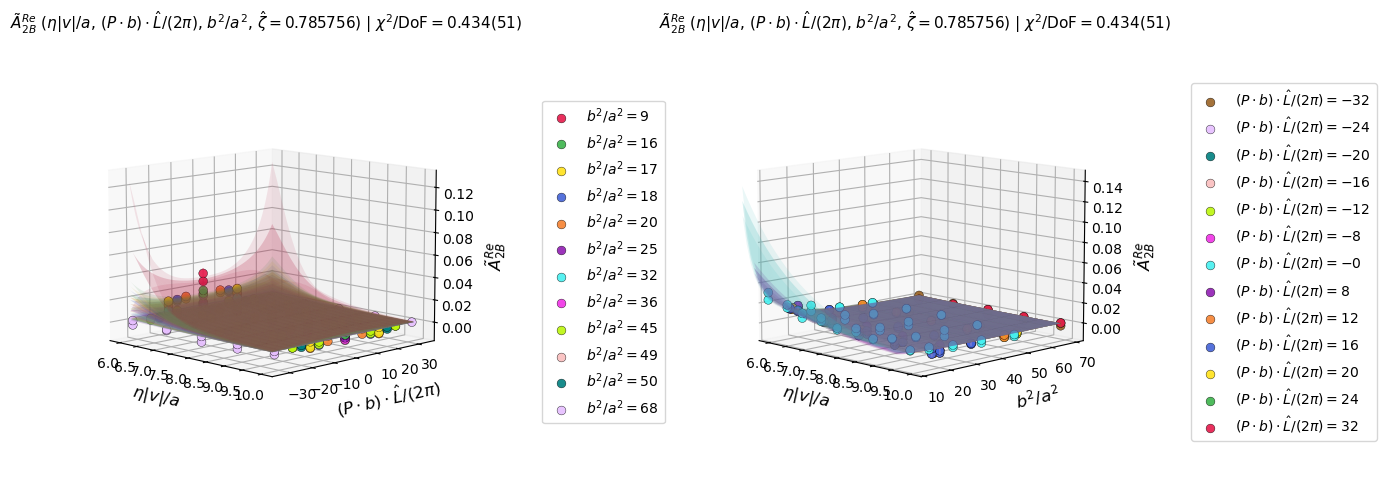

Processing 3D plots for ImA2B...
Saved: ImA2B_Pb_bsq_PL-4_WithFit_3D.pdf


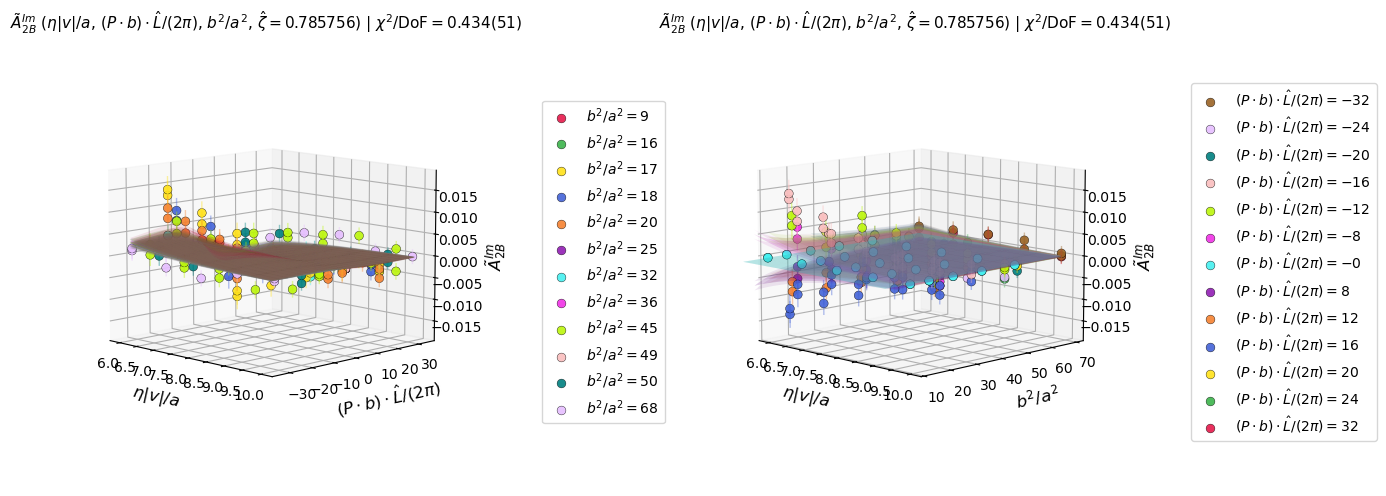

Processing 3D plots for ReA12B...
Saved: ReA12B_Pb_bsq_PL-4_WithFit_3D.pdf


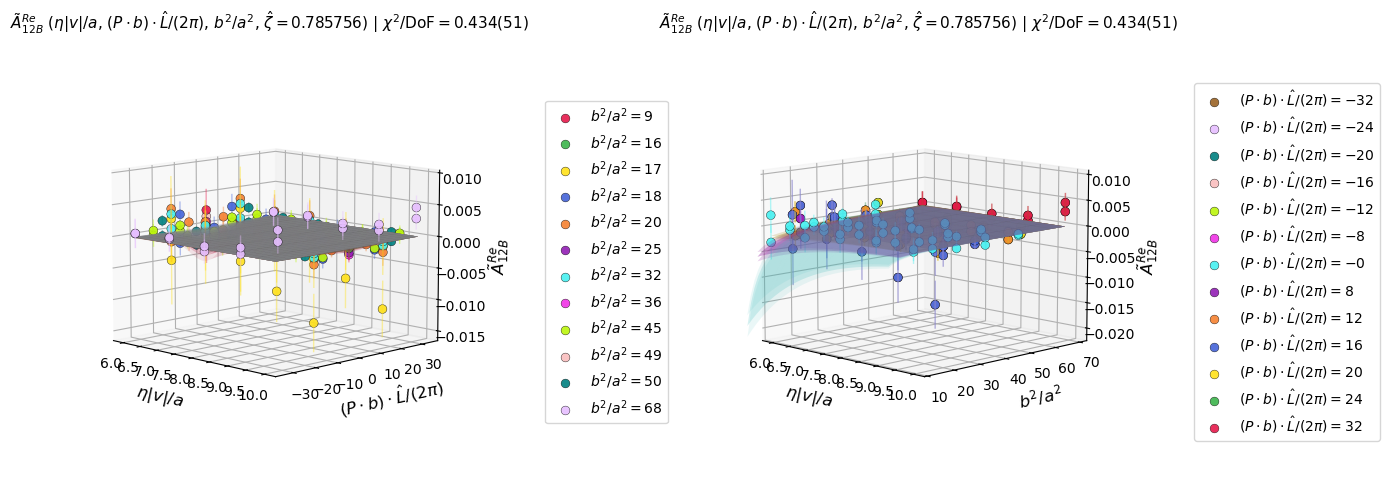

Processing 2D plots at fixed eta=8...
Saved: Combined_Pb_bsq_eta8_PL-4_WithFit_2D.pdf


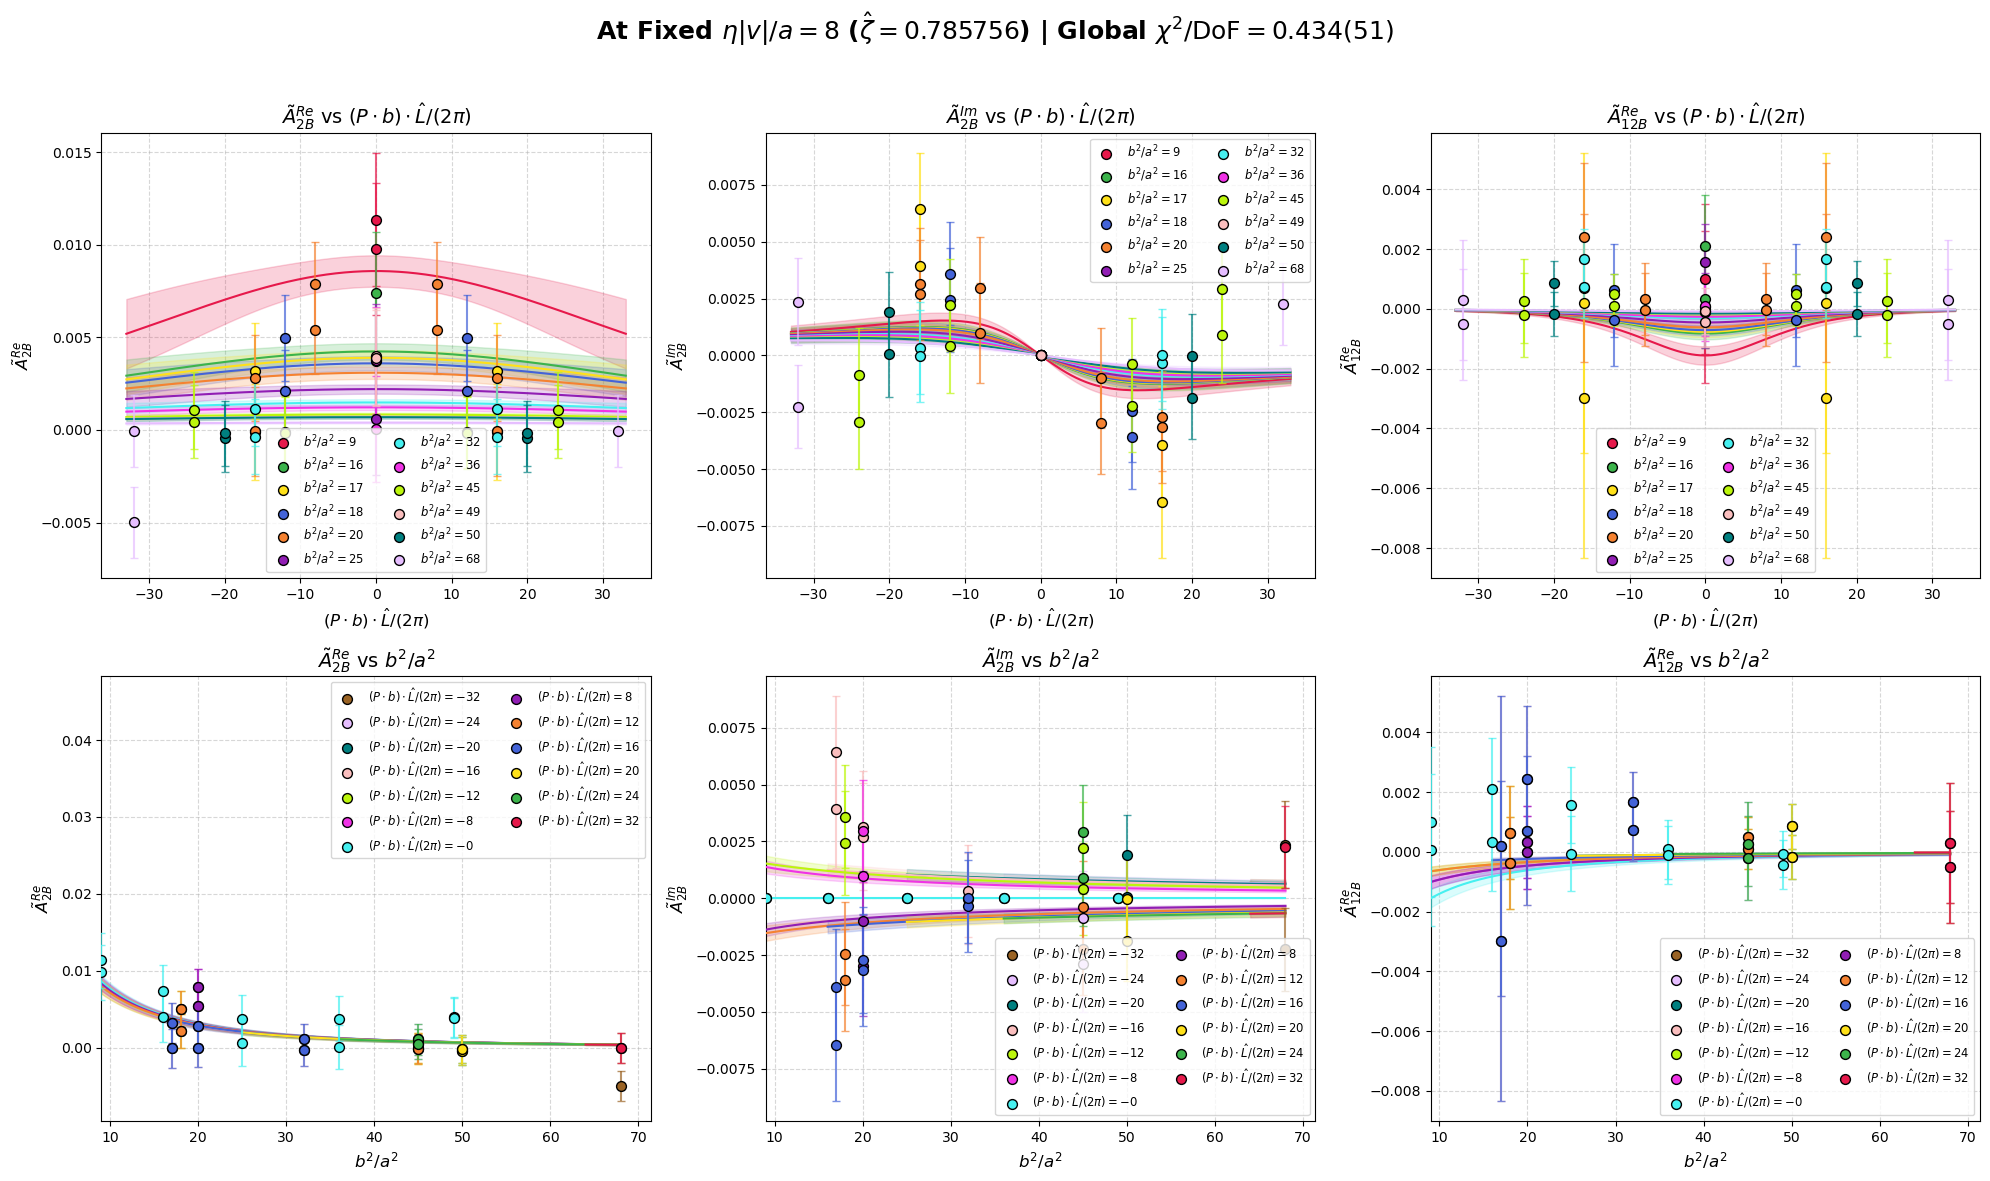

In [29]:
import h5py
import numpy as np
import math
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# --- 1. Jackknife Functions ---
def jackknife_vectorized(samples):
    N = samples.shape[1]
    theta_bar = np.mean(samples, axis=1)
    squared_diffs = np.square(samples - theta_bar[:, None])
    sigma_sq = ((N - 1) / N) * np.sum(squared_diffs, axis=1)
    error = np.sqrt(sigma_sq)
    return theta_bar, error

def Jackknife(datalist): 
    N = len(datalist)
    theta_bar = np.mean(datalist)
    theta_nminus_theta_bar = []
    for i in range(N): 
        theta_n = datalist[i]
        theta_nminus_theta_bar.append(np.square(theta_n - theta_bar))
    sigma_sq = ((N-1)/N) * np.sum(theta_nminus_theta_bar)
    return theta_bar, np.sqrt(sigma_sq)

def fmt_err(mean, err):
    # Fallback for 0 or negative error
    if err <= 0:
        return f"{mean}"
        
    # Switch to scientific if very small/big
    if mean and (abs(mean) < 1e-3 or abs(mean) >= 1e3):
        # Calculate exponent of the mean
        exp = int(math.floor(math.log10(abs(mean))))
        mean_scaled = mean / 10**exp
        err_scaled = err / 10**exp
        
        # Find precision needed for exactly 2 significant digits of the error
        place = int(math.floor(math.log10(abs(err_scaled))))
        ndec = max(0, -(place - 1))
        
        m_str = f"{mean_scaled:.{ndec}f}"
        err_int = int(round(err_scaled * 10**ndec))
        return f"{m_str}({err_int})e{exp}"
        
    else:
        # Find precision needed for exactly 2 significant digits of the error
        place = int(math.floor(math.log10(abs(err))))
        ndec = max(0, -(place - 1))  # -1 gives us 2 sig figs instead of 1
        
        m_str = f"{mean:.{ndec}f}"
        err_int = int(round(err * 10**ndec))
        return f"{m_str}({err_int})"
        
pl_to_zeta = {
    -4: 0.785756,
    -3: 0.539684,
    -2: 0.294367,
    -1: 0.090772
}

# --- 2. Data Loading Helper ---
def get_processed_amplitude_data(filepath, PL):
    try:
        with h5py.File(filepath, "r") as f:
            raw_data = f["Dataset1"][:]
    except FileNotFoundError:
        print(f"File not found: {filepath}")
        return None

    kin = raw_data[:, 0:3]
    samples = raw_data[:, 3:]
    
    eta, bL, bT = kin[:, 0], kin[:, 1], kin[:, 2]
    
    # Filter only for eta from 1 to 10 (keeps bL=bT=0 and eta=1..5)
    mask_eta = (eta >= 6) & (eta <= 10) & (np.sqrt(bL**2+bT**2)>=3)
    eta_f, bL_f, bT_f = eta[mask_eta], bL[mask_eta], bT[mask_eta]
    
    # NEW: Calculate P.b and b^2
    P_dot_b_f = np.round(bL_f * float(PL), 5)
    b_sq_f = np.round(bL_f**2 + bT_f**2, 5)
    
    mean_f, err_f = jackknife_vectorized(samples[mask_eta])
    
    return {
        'eta': eta_f, 'bL': bL_f, 'bT': bT_f,
        'P_dot_b': P_dot_b_f, 'b_sq': b_sq_f,
        'mean': mean_f, 'error': err_f,
        'unique_P_dot_b': np.unique(P_dot_b_f), 'unique_b_sq': np.unique(b_sq_f),
        'r': np.sqrt(bL_f**2 + bT_f**2)
    }

# --- 3. STRICTLY Distinct Color Generator ---
def get_distinct_colors(num_colors):
    """Returns a list of highly distinct, non-gradient colors."""
    distinct_hex = [
        '#e6194b', '#3cb44b', '#ffe119', '#4363d8', '#f58231',
        '#911eb4', '#46f0f0', '#f032e6', '#bcf60c', '#fabebe',
        '#008080', '#e6beff', '#9a6324', '#fffac8', '#800000',
        '#aaffc3', '#808000', '#ffd8b1', '#000075', '#808080',
        '#000000', '#333333'
    ]
    return [distinct_hex[i % len(distinct_hex)] for i in range(num_colors)]

# --- 4. Fit Evaluation Helper ---
def eval_fit_jk(amp_name, eta, bL, bT_sq, params):
    """Evaluates the fit model over input arrays and returns the Jackknife mean and error.
       Now accepts bT_sq directly to allow plotting across the full algebraic domain."""
    eta = np.atleast_1d(eta)
    bL = np.atleast_1d(bL)
    bT_sq = np.atleast_1d(bT_sq)
    
    if amp_name == "ReA2B":
        a, c, d, f = params['a_re'], params['c_re'], params['d_re'], params['f']
        k1, k2, j = params['k1_re'], params['k2_re'], params['j_re']
        
        a, c, d, f = a[:, None], c[:, None], d[:, None], f[:, None]
        k1, k2, j = k1[:, None], k2[:, None], j[:, None]
        
        # Swapped bT**2 for bT_sq
        denom = (1 + (d + c * (1 - k1/eta - k2/eta**2)) * bL**2 + d * bT_sq)**j
        val = a * np.exp(-f * eta) / denom
        
    elif amp_name == "ImA2B":
        a, c, d, f = params['a_im'], params['c_im'], params['d_im'], params['f']
        j = params['j_im']
        a, c, d, f, j = a[:, None], c[:, None], d[:, None], f[:, None], j[:, None]
        
        # Swapped bT**2 for bT_sq
        denom = (1 + (c + d) * bL**2 + d * bT_sq)**j
        val = a * bL * np.exp(-f * eta) / denom
        
    elif amp_name == "ReA12B":
        a, c, d, f = params['a_reA12B'], params['c_reA12B'], params['d_reA12B'], params['f']
        j = params['j_reA12B']
        a, c, d, f, j = a[:, None], c[:, None], d[:, None], f[:, None], j[:, None]
        
        # Swapped bT**2 for bT_sq
        denom = (1 + (c + d) * bL**2 + d * bT_sq)**j
        val = -a * np.exp(-f * eta) / denom
        
    N = val.shape[0]
    mean_val = np.mean(val, axis=0)
    squared_diffs = np.square(val - mean_val)
    err_val = np.sqrt(((N - 1) / N) * np.sum(squared_diffs, axis=0))
    
    return mean_val, err_val

def eval_fit_jk_new_coords(amp_name, eta, P_dot_b, b_sq, params, PL):
    """NEW: Wrapper to evaluate in P.b and b^2. Masking removed to allow full-grid visualization."""
    bL = P_dot_b / float(PL)
    bT_sq = b_sq - bL**2
    
    # Pass bT_sq directly, bypassing the need for bT to be a real number
    mean_val, err_val = eval_fit_jk(amp_name, eta, bL, bT_sq, params)
    
    return mean_val, err_val

# --- 5. 3D Plotting Function ---
def plot_3d_for_amplitude(data, amp_name, PL, fitted_params, chi2_str):
    fig = plt.figure(figsize=(16, 9))
    
    if amp_name == "ReA2B":
        amp_print = "$\\tilde{{A}}_{{2B}}^{{Re}}$"
    elif amp_name == "ImA2B":
        amp_print = "$\\tilde{{A}}_{{2B}}^{{Im}}$"
    elif amp_name == "ReA12B":
        amp_print = "$\\tilde{{A}}_{{12B}}^{{Re}}$"
        
    # Valid global bounds for fit grid (strictly evaluated over the colored valid region)
    valid_global_mask = (data['r'] >= 3) & (data['eta'] >= 6)
    
    # NEW: Global limits for P.b and b^2 grids
    global_max_b_sq = np.max(data['b_sq'][valid_global_mask])
    global_max_Pb = np.sqrt(global_max_b_sq) * abs(float(PL))
    
    # Fit ETA grid strictly spans from 6 upward, avoiding 1-5
    eta_grid = np.linspace(6.0, np.max(data['eta']), 30)
    
    title_str = fr'{amp_print} ($\eta|v|/a$, $(P \cdot b)\cdot \hat{{L}} / (2\pi)$, $b^2/a^2$, $\hat{{\zeta}}={pl_to_zeta[int(PL)]}$) | $\chi^2/\mathrm{{DoF}}={chi2_str}$'
    
    # --- Plot 1: Y-axis is P.b, Color by distinct b^2 ---
    ax1 = fig.add_subplot(121, projection='3d')
    unique_b_sq = data['unique_b_sq']
    colors_b_sq = get_distinct_colors(len(unique_b_sq))
    
    for i, val_b_sq in enumerate(unique_b_sq):
        mask = (data['b_sq'] == val_b_sq)
        mask_valid = mask & (data['r'] >= 3) & (data['eta'] >= 6)
        mask_invalid = mask & ((data['r'] < 3) | (data['eta'] < 6))
        
        # Valid points (colored circles)
        if np.any(mask_valid):
            ax1.scatter(data['eta'][mask_valid], data['P_dot_b'][mask_valid], data['mean'][mask_valid], 
                        color=colors_b_sq[i], label=fr'$b^2/a^2={val_b_sq:.0f}$', 
                        marker='o', s=40, alpha=0.9, edgecolors='k', linewidth=0.3)
            ax1.errorbar(data['eta'][mask_valid], data['P_dot_b'][mask_valid], data['mean'][mask_valid], 
                         zerr=data['error'][mask_valid], fmt='none', ecolor=colors_b_sq[i], 
                         alpha=0.4, linewidth=1.0, zorder=0)
                         
            # Fit Surface over full valid global P.b range
            P_dot_b_grid = np.linspace(-global_max_Pb, global_max_Pb, 100)
            ETA, P_DOT_B = np.meshgrid(eta_grid, P_dot_b_grid)
            
            mean_surf, err_surf = eval_fit_jk_new_coords(amp_name, ETA.flatten(), P_DOT_B.flatten(), np.full_like(ETA.flatten(), val_b_sq), fitted_params, PL)
            mean_surf = mean_surf.reshape(ETA.shape)
            err_surf = err_surf.reshape(ETA.shape)
            
            ax1.plot_surface(ETA, P_DOT_B, mean_surf, color=colors_b_sq[i], alpha=0.2, rstride=5, cstride=5)
            ax1.plot_surface(ETA, P_DOT_B, mean_surf + err_surf, color=colors_b_sq[i], alpha=0.1, rstride=5, cstride=5)
            ax1.plot_surface(ETA, P_DOT_B, mean_surf - err_surf, color=colors_b_sq[i], alpha=0.1, rstride=5, cstride=5)

        # Invalid points (gray 'x')
        if np.any(mask_invalid):
            ax1.scatter(data['eta'][mask_invalid], data['P_dot_b'][mask_invalid], data['mean'][mask_invalid], 
                        color='gray', marker='x', s=35, alpha=0.7)
            ax1.errorbar(data['eta'][mask_invalid], data['P_dot_b'][mask_invalid], data['mean'][mask_invalid], 
                         zerr=data['error'][mask_invalid], fmt='none', ecolor='gray', 
                         alpha=0.4, linewidth=1.0, zorder=0)

    ax1.set_xlabel(r'$\eta|v|/a$', fontsize=12, labelpad=10)
    ax1.set_ylabel(r'$(P \cdot b) \cdot \hat{L} / (2\pi)$', fontsize=12, labelpad=10)
    ax1.set_zlabel(f'{amp_print}', fontsize=12, labelpad=10)
    ax1.set_title(title_str, fontsize=11)
    ax1.legend(loc='center left', bbox_to_anchor=(1.1, 0.5), ncol=1)

    # --- Plot 2: Y-axis is b^2, Color by distinct P.b ---
    ax2 = fig.add_subplot(122, projection='3d')
    unique_P_dot_b = data['unique_P_dot_b']
    colors_P_dot_b = get_distinct_colors(len(unique_P_dot_b))[::-1] 

    for i, val_P_dot_b in enumerate(unique_P_dot_b):
        mask = (data['P_dot_b'] == val_P_dot_b)
        mask_valid = mask & (data['r'] >= 3) & (data['eta'] >= 6)
        mask_invalid = mask & ((data['r'] < 3) | (data['eta'] < 6))
        
        # Valid points (colored circles)
        if np.any(mask_valid):
            ax2.scatter(data['eta'][mask_valid], data['b_sq'][mask_valid], data['mean'][mask_valid], 
                        color=colors_P_dot_b[i], label=fr'$(P \cdot b)\cdot \hat{{L}} / (2\pi)={val_P_dot_b:.0f}$', 
                        marker='o', s=40, alpha=0.9, edgecolors='k', linewidth=0.3)
            ax2.errorbar(data['eta'][mask_valid], data['b_sq'][mask_valid], data['mean'][mask_valid], 
                         zerr=data['error'][mask_valid], fmt='none', ecolor=colors_P_dot_b[i], 
                         alpha=0.4, linewidth=1.0, zorder=0)

            # Fit Surface over global b^2 range
            min_bsq_for_this_Pb = (val_P_dot_b / float(PL))**2
            b_sq_grid = np.linspace(min_bsq_for_this_Pb, global_max_b_sq, 50)
            ETA, B_SQ = np.meshgrid(eta_grid, b_sq_grid)
            
            mean_surf, err_surf = eval_fit_jk_new_coords(amp_name, ETA.flatten(), np.full_like(ETA.flatten(), val_P_dot_b), B_SQ.flatten(), fitted_params, PL)
            mean_surf = mean_surf.reshape(ETA.shape)
            err_surf = err_surf.reshape(ETA.shape)
            
            ax2.plot_surface(ETA, B_SQ, mean_surf, color=colors_P_dot_b[i], alpha=0.2, rstride=5, cstride=5)
            ax2.plot_surface(ETA, B_SQ, mean_surf + err_surf, color=colors_P_dot_b[i], alpha=0.1, rstride=5, cstride=5)
            ax2.plot_surface(ETA, B_SQ, mean_surf - err_surf, color=colors_P_dot_b[i], alpha=0.1, rstride=5, cstride=5)

        # Invalid points (gray 'x')
        if np.any(mask_invalid):
            ax2.scatter(data['eta'][mask_invalid], data['b_sq'][mask_invalid], data['mean'][mask_invalid], 
                        color='gray', marker='x', s=35, alpha=0.7)
            ax2.errorbar(data['eta'][mask_invalid], data['b_sq'][mask_invalid], data['mean'][mask_invalid], 
                         zerr=data['error'][mask_invalid], fmt='none', ecolor='gray', 
                         alpha=0.4, linewidth=1.0, zorder=0)

    ax2.set_xlabel(r'$\eta|v|/a$', fontsize=12, labelpad=10)
    ax2.set_ylabel(r'$b^2/a^2$', fontsize=12, labelpad=10)
    ax2.set_zlabel(f'{amp_print}', fontsize=12, labelpad=10)
    ax2.set_ylim(bottom=9)
    ax2.set_title(title_str, fontsize=11)
    ax2.legend(loc='center left', bbox_to_anchor=(1.1, 0.5), ncol=1)

    ax1.view_init(elev=10, azim=-45) 
    ax2.view_init(elev=10, azim=-45)

    try:
        ax1.set_box_aspect(None, zoom=0.8)
        ax2.set_box_aspect(None, zoom=0.8)
    except AttributeError:
        ax1.dist = 11
        ax2.dist = 11

    plt.tight_layout(rect=[0.02, 0.05, 0.88, 0.95])
    return fig

# --- 6. 2D Plot at fixed eta = 8 ---
def plot_2d_slice_eta8(all_data_dict, PL, fitted_params, chi2_str):
    fig, axes = plt.subplots(2, 3, figsize=(20, 12))
    fig.suptitle(fr'At Fixed $\eta|v|/a = 8$ ($\hat{{\zeta}}={pl_to_zeta[int(PL)]}$) | Global $\chi^2/\mathrm{{DoF}}={chi2_str}$', fontsize=18, fontweight='bold')
    
    for idx, (amp_name, data) in enumerate(all_data_dict.items()):
        if amp_name == "ReA2B":
            amp_print = "$\\tilde{{A}}_{{2B}}^{{Re}}$"
        elif amp_name == "ImA2B":
            amp_print = "$\\tilde{{A}}_{{2B}}^{{Im}}$"
        elif amp_name == "ReA12B":
            amp_print = "$\\tilde{{A}}_{{12B}}^{{Re}}$"
            
        if data is None: continue
        
        ax_top = axes[0, idx]
        ax_bot = axes[1, idx]
        
        mask_eta8 = np.isclose(data['eta'], 8.0)
        P_dot_b_8 = data['P_dot_b'][mask_eta8]
        b_sq_8 = data['b_sq'][mask_eta8]
        mean_8 = data['mean'][mask_eta8]
        err_8 = data['error'][mask_eta8]
        r_8 = data['r'][mask_eta8]
        
        # Valid bounds over the global set of valid colored points
        valid_global_mask = (data['r'] >= 3) & (data['eta'] >= 6)
        global_max_b_sq = np.max(data['b_sq'][valid_global_mask])
        global_max_Pb = np.sqrt(global_max_b_sq) * abs(float(PL))
        
        if len(P_dot_b_8) == 0:
            ax_top.text(0.5, 0.5, "No data", ha='center', va='center')
            ax_bot.text(0.5, 0.5, "No data", ha='center', va='center')
            continue
            
        # ==========================================
        # TOP ROW: Amplitude vs P.b, colored by b^2
        # ==========================================
        unique_b_sq = np.unique(b_sq_8)
        colors_b_sq = get_distinct_colors(len(unique_b_sq))
        
        for i, val_b_sq in enumerate(unique_b_sq):
            sub_mask = (b_sq_8 == val_b_sq)
            # Eta is strictly 8 here, so validity just depends on r
            mask_valid = sub_mask & (r_8 >= 3)
            mask_invalid = sub_mask & (r_8 < 3)
            
            # Valid points
            if np.any(mask_valid):
                ax_top.scatter(P_dot_b_8[mask_valid], mean_8[mask_valid], color=colors_b_sq[i], 
                               label=fr'$b^2/a^2={val_b_sq:.0f}$', marker='o', zorder=5, s=50, edgecolors='k')
                ax_top.errorbar(P_dot_b_8[mask_valid], mean_8[mask_valid], yerr=err_8[mask_valid], 
                                fmt='none', ecolor=colors_b_sq[i], alpha=0.7, zorder=4, capsize=3)
                
                # Fit Band over valid global P.b range
                P_dot_b_grid = np.linspace(-global_max_Pb, global_max_Pb, 500)
                mean_fit, err_fit = eval_fit_jk_new_coords(amp_name, np.full_like(P_dot_b_grid, 8.0), P_dot_b_grid, np.full_like(P_dot_b_grid, val_b_sq), fitted_params, PL)
                ax_top.plot(P_dot_b_grid, mean_fit, color=colors_b_sq[i], linestyle='-', zorder=3)
                ax_top.fill_between(P_dot_b_grid, mean_fit - err_fit, mean_fit + err_fit, color=colors_b_sq[i], alpha=0.2, zorder=2)
            
            # Invalid points
            if np.any(mask_invalid):
                ax_top.scatter(P_dot_b_8[mask_invalid], mean_8[mask_invalid], color='gray', marker='x', 
                               zorder=5, s=40)
                ax_top.errorbar(P_dot_b_8[mask_invalid], mean_8[mask_invalid], yerr=err_8[mask_invalid], 
                                fmt='none', ecolor='gray', alpha=0.7, zorder=4, capsize=3)
        
        ax_top.set_title(fr'{amp_print} vs $(P \cdot b)\cdot \hat{{L}} / (2\pi)$', fontsize=14)
        ax_top.set_xlabel(r'$(P \cdot b) \cdot \hat{L} / (2\pi)$', fontsize=12)
        ax_top.set_ylabel(f'{amp_print}', fontsize=12)
        ax_top.grid(True, linestyle='--', alpha=0.5)
        ax_top.legend(fontsize='small', loc='best', ncol=(1 if len(unique_b_sq) <= 6 else 2))

        # ==========================================
        # BOTTOM ROW: Amplitude vs b^2, colored by P.b
        # ==========================================
        unique_P_dot_b = np.unique(P_dot_b_8)
        colors_P_dot_b = get_distinct_colors(len(unique_P_dot_b))[::-1] 
        
        for i, val_P_dot_b in enumerate(unique_P_dot_b):
            sub_mask = (P_dot_b_8 == val_P_dot_b)
            mask_valid = sub_mask & (r_8 >= 3)
            mask_invalid = sub_mask & (r_8 < 3)
            
            # Valid points
            if np.any(mask_valid):
                ax_bot.scatter(b_sq_8[mask_valid], mean_8[mask_valid], color=colors_P_dot_b[i], 
                               label=fr'$(P \cdot b)\cdot \hat{{L}} / (2\pi)={val_P_dot_b:.0f}$', marker='o', zorder=5, s=50, edgecolors='k')
                ax_bot.errorbar(b_sq_8[mask_valid], mean_8[mask_valid], yerr=err_8[mask_valid], 
                                fmt='none', ecolor=colors_P_dot_b[i], alpha=0.7, zorder=4, capsize=3)
                
                # Fit Band over valid b^2 range
                min_bsq_for_this_Pb = (val_P_dot_b / float(PL))**2
                b_sq_grid = np.linspace(min_bsq_for_this_Pb, global_max_b_sq, 300)
                mean_fit, err_fit = eval_fit_jk_new_coords(amp_name, np.full_like(b_sq_grid, 8.0), np.full_like(b_sq_grid, val_P_dot_b), b_sq_grid, fitted_params, PL)
                ax_bot.plot(b_sq_grid, mean_fit, color=colors_P_dot_b[i], linestyle='-', zorder=3)
                ax_bot.fill_between(b_sq_grid, mean_fit - err_fit, mean_fit + err_fit, color=colors_P_dot_b[i], alpha=0.2, zorder=2)

            # Invalid points
            if np.any(mask_invalid):
                ax_bot.scatter(b_sq_8[mask_invalid], mean_8[mask_invalid], color='gray', marker='x', 
                               zorder=5, s=40)
                ax_bot.errorbar(b_sq_8[mask_invalid], mean_8[mask_invalid], yerr=err_8[mask_invalid], 
                                fmt='none', ecolor='gray', alpha=0.7, zorder=4, capsize=3)
        
        ax_bot.set_title(fr'{amp_print} vs $b^2/a^2$', fontsize=14)
        ax_bot.set_xlim(left=9)
        ax_bot.set_xlabel(r'$b^2/a^2$', fontsize=12)
        ax_bot.set_ylabel(f'{amp_print}', fontsize=12)
        ax_bot.grid(True, linestyle='--', alpha=0.5)
        ax_bot.legend(fontsize='small', loc='best', ncol=(1 if len(unique_P_dot_b) <= 6 else 2))

    plt.tight_layout(rect=[0, 0, 1, 0.96])
    return fig


def load_params_from_h5(filename):
    fitted_params = {}
    with h5py.File(filename, "r") as f:
        param_group = f["jackknife_samples"]
        for key in param_group.keys():
            fitted_params[key] = param_group[key][:]
        chi2_dof_list = f["chi2_dof"][:]
    return fitted_params, chi2_dof_list 

def print_latex_table(fitted_params, chi2_dof_list, PL, bmin, etamin, etamax, chi2_str):
    res = {}
    for key in fitted_params:
        mean, err = Jackknife(fitted_params[key])
        res[key] = fmt_err(mean, err)
        
    re_params = ['a_re', 'c_re', 'd_re', 'k1_re', 'k2_re', 'j_re', 'f']
    im_params = ['a_im', 'c_im', 'd_im', 'j_im', 'f']
    a12b_params = ['a_reA12B', 'c_reA12B', 'd_reA12B', 'j_reA12B', 'f']

    vals_re = ", ".join([res[p] for p in re_params])
    vals_im = ", ".join([res[p] for p in im_params])
    vals_a12b = ", ".join([res[p] for p in a12b_params])

    eq_re = r"$\frac{a e^{-f \eta}}{\left[1 + \left(d + c\left(1 - \frac{k_1}{\eta} - \frac{k_2}{\eta^2}\right)\right) b_L^2 + d b_T^2\right]^j}$"
    eq_im = r"$\frac{a b_L e^{-f \eta}}{\left[1 + (c + d) b_L^2 + d b_T^2\right]^j}$"
    eq_a12b = r"$\frac{-a e^{-f \eta}}{\left[1 + (c + d) b_L^2 + d b_T^2\right]^j}$"

    names_re = r"$\{a, c, d, k_1, k_2, j, f\}$"
    names_im = r"$\{a, c, d, j, f\}$"
    names_a12b = r"$\{a, c, d, j, f\}$"
    
    tex = "\\begin{table}[htpb]\n\\centering\n"
    tex += "\\renewcommand{\\arraystretch}{1.5}\n" 
    tex += f"\\caption{{Simultaneous Fit with common $f$: for $P_L={PL}$, $b_{{min}} \\ge {bmin}$, $\\eta \\in [{etamin}, {etamax}]$. Global $\\chi^2/\\text{{DoF}} = {chi2_str}$}}\n"
    tex += "\\scalebox{0.8}{\\begin{tabular}{|l|l|l|l|}\n\\hline\n"
    tex += "Amplitude & Model Expression & Params List & Fitted Values \\\\\n\\hline\n"
    tex += f"Re$A_{{2B}}$ & {eq_re} & {names_re} & $[{vals_re}]$ \\\\\n"
    tex += f"Im$A_{{2B}}$ & {eq_im} & {names_im} & $[{vals_im}]$ \\\\\n"
    tex += f"Re$A_{{12B}}$ & {eq_a12b} & {names_a12b} & $[{vals_a12b}]$ \\\\\n"
    tex += "\\hline\n\\end{tabular}}\n\\end{table}\n"

    filename = f"Fit_Table_PL{PL}_bmin{bmin}.tex"
    with open(filename, "w") as f:
        f.write(tex)

# ==========================================
# Main Execution Block
# ==========================================
PL_value = "-4" 
bminfit = 3
etamin = 6
etamax = 10
path_base = "/pscratch/sd/h/hari_8/TMD_fit/h5data"

# 1. Load fitted parameters
fit_file = f"{path_base}/FitParams_SimulFit_f_A2BRe_cetasq_A2BIm_A12BRe_bmin{bminfit}_eta{etamin}{etamax}_PL{PL_value}.h5"
fitted_params, chi2_dof_list = load_params_from_h5(fit_file)

# Compute chi2 string here so we can pass it to the plotting functions
mean_chi2, err_chi2 = Jackknife(chi2_dof_list)
chi2_str = fmt_err(mean_chi2, err_chi2)

# Update print table to receive chi2_str
print_latex_table(fitted_params, chi2_dof_list, PL_value, bminfit, etamin, etamax, chi2_str)

# 2. Data loading paths
amplitude_files = {
    "ReA2B":  f"{path_base}/ReA2B_PL{PL_value}_jackknife_data.h5",
    "ImA2B":  f"{path_base}/ImA2B_PL{PL_value}_jackknife_data.h5",
    "ReA12B": f"{path_base}/ReA12B_PL{PL_value}_jackknife_data.h5"
}

processed_data_store = {}

# 3. Generate and Save 3D Plots
for amp_name, file_path in amplitude_files.items():
    print(f"Processing 3D plots for {amp_name}...")
    # NEW: Passing PL_value to the data loader
    amplitude_data = get_processed_amplitude_data(file_path, PL_value)
    if amplitude_data is not None:
        processed_data_store[amp_name] = amplitude_data
        
        # Pass chi2_str to 3D plot
        fig_3d = plot_3d_for_amplitude(amplitude_data, amp_name, PL_value, fitted_params, chi2_str)
        
        save_name_3d = f"{amp_name}_Pb_bsq_PL{PL_value}_WithFit_3D.pdf"
        plt.savefig(save_name_3d, format='pdf', dpi=300, bbox_inches='tight')
        print(f"Saved: {save_name_3d}")
        plt.show()

# 4. Generate and Save Combined 2D Plots (eta=8)
print("Processing 2D plots at fixed eta=8...")
if processed_data_store:
    # Pass chi2_str to 2D plot
    fig_2d = plot_2d_slice_eta8(processed_data_store, PL_value, fitted_params, chi2_str)
    
    save_name_2d = f"Combined_Pb_bsq_eta8_PL{PL_value}_WithFit_2D.pdf"
    plt.savefig(save_name_2d, format='pdf', dpi=300, bbox_inches='tight')
    print(f"Saved: {save_name_2d}")
    plt.show()